# Smart Street Lighting Efficiency
<div class="usecase-authors"><b>Authored by: </b> Binul Bijo and Kliona Kennet</div>

<div class="usecase-duration"><b>Duration:</b> 60 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level:</b> Beginner</div>
    <div class="usecase-skill"><b>Pre-requisite Skills:</b> Python, Pandas, Matplotlib, basic data analysis</div>
</div>

<div class="usecase-section-header">Scenario</div>

Cities often use fixed street lighting schedules even though traffic and pedestrian activity changes throughout the day. This can lead to unnecessary energy use during low-activity hours and insufficient lighting during busy periods.

This use case explores how streetlight, traffic, and pedestrian datasets can be combined to support smarter lighting efficiency decisions.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case, you will be able to:

- Load and inspect multiple urban datasets
- Clean streetlight, traffic, and pedestrian data
- Create hourly traffic and pedestrian activity measures
- Integrate datasets using time-based analysis
- Calculate a demand score
- Classify lighting as under-lit, efficient, or over-lit
- Generate practical smart lighting recommendations

## 1. Importing packages

This section imports the Python libraries needed for data handling, numerical operations, visualisation, and saving output files.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

**Explanation:**  
This code imports the main Python libraries used in the notebook. `pandas` is used for reading, cleaning, and analysing tabular datasets. `numpy` supports numerical operations. `matplotlib` is used to create charts, and `os` is used to create an output folder for saving graphs and final results.

**Expected output:**  
This cell does not display a visible output. It prepares the notebook environment so the later data processing and visualisation steps can run.

## 2. Creating output folder

The output folder stores generated charts and the final CSV summary. This makes the notebook evidence easier to upload to GitHub and use in the final submission.

In [5]:
os.makedirs("outputs", exist_ok=True)

**Explanation:**  
This code creates an `outputs` folder if it does not already exist. The folder is used to store generated charts and final result files.

**Output interpretation:**  
There may be no visible output from this cell. If the code runs without error, it means the folder has been created successfully or already exists.

## 3. Loading datasets

This section loads the three CSV files into pandas DataFrames. The shape and column names are printed to verify that the datasets have loaded correctly and to understand their structure before cleaning.

In [6]:
import pandas as pd
street_url = "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00240_Smart_Street_Lighting_Efficiency/streetlight.csv"
street = pd.read_csv(street_url)
traffic_url = "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00240_Smart_Street_Lighting_Efficiency/traffic.csv"
traffic = pd.read_csv(traffic_url)
ped_aa_url = "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00240_Smart_Street_Lighting_Efficiency/pedestrian_part_aa.csv"

ped_ab_url = "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00240_Smart_Street_Lighting_Efficiency/pedestrian_part_ab.csv"

ped_ac_url = "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00240_Smart_Street_Lighting_Efficiency/pedestrian_part_ac.csv"

ped_ad_url = "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00240_Smart_Street_Lighting_Efficiency/pedestrian_part_ad.csv"

ped_ae_url = "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/master/datascience/usecases/DEPENDENCIES/UC00240_Smart_Street_Lighting_Efficiency/pedestrian_part_ae.csv"
ped_aa = pd.read_csv(ped_aa_url)

ped_ab = pd.read_csv(ped_ab_url)
ped_ab.columns = ped_aa.columns

ped_ac = pd.read_csv(ped_ac_url)
ped_ac.columns = ped_aa.columns

ped_ad = pd.read_csv(ped_ad_url)
ped_ad.columns = ped_aa.columns

ped_ae = pd.read_csv(ped_ae_url)
ped_ae.columns = ped_aa.columns

ped = pd.concat(
    [ped_aa, ped_ab, ped_ac, ped_ad, ped_ae],
    ignore_index=True
)

print("Streetlight dataset shape:", street.shape)
print("Traffic dataset shape:", traffic.shape)
print("Pedestrian dataset shape:", ped.shape)

print("\nStreetlight columns:")
print(street.columns.tolist())

print("\nTraffic columns:")
print(traffic.columns.tolist())

print("\nPedestrian columns:")
print(ped.columns.tolist())

Streetlight dataset shape: (106037, 21)
Traffic dataset shape: (60168, 28)
Pedestrian dataset shape: (1472098, 9)

Streetlight columns:
['Geo Point', 'Geo Shape', 'prop_id', 'name', 'addresspt1', 'xorg', 'ext_id', 'asset_clas', 'label', 'asset_type', 'easting', 'northing', 'str_id', 'addresspt_', 'asset_subt', 'xsource', 'profile', 'xdate', 'xdrawing', 'mcc_id', 'roadseg_id']

Traffic columns:
['date', 'road_name', 'location', 'suburb', 'speed_limit', 'direction', 'time', 'vehicle_class_1', 'vehicle_class_2', 'vehicle_class_3', 'vehicle_class_4', 'vehicle_class_5', 'vehicle_class_6', 'vehicle_class_7', 'vehicle_class_8', 'vehicle_class_9', 'vehicle_class_10', 'vehicle_class_11', 'vehicle_class_12', 'vehicle_class_13', 'motorcycle', 'bike', 'average_speed', '85th_percentile_speed', 'maximum_speed', 'road_segment', 'road_segment_1', 'road_segment_2']

Pedestrian columns:
['ID', 'Location_ID', 'Sensing_Date', 'HourDay', 'Direction_1', 'Direction_2', 'Total_of_Directions', 'Sensor_Name', '

**Explanation:**  
This section loads the streetlight, traffic, and pedestrian datasets. The streetlight and traffic datasets are loaded from GitHub dependency links, while the pedestrian dataset is loaded from local chunk files and combined into one dataframe.

**Output interpretation:**  
The printed shapes show the number of rows and columns in each dataset. The column lists help confirm that the correct files were loaded and that the required fields are available for cleaning and analysis.

## 4. Streetlight data cleaning

The streetlight dataset includes a `Geo Point` column containing latitude and longitude together. This step separates the coordinates, converts them into numeric values, removes missing coordinate records, and calculates key summary measures such as total streetlights and average lux level.

In [7]:
street[['latitude', 'longitude']] = street['Geo Point'].str.split(',', expand=True)

street['latitude'] = pd.to_numeric(street['latitude'], errors='coerce')
street['longitude'] = pd.to_numeric(street['longitude'], errors='coerce')

street_clean = street.dropna(subset=['latitude', 'longitude']).copy()

print("\nCleaned streetlight dataset shape:", street_clean.shape)

streetlight_count = len(street_clean)
avg_lux = street_clean['label'].mean()

print("Total streetlights:", streetlight_count)
print("Average lux level:", avg_lux)


Cleaned streetlight dataset shape: (106037, 23)
Total streetlights: 106037
Average lux level: 15.044991738732708


**Explanation:**  
This code cleans the streetlight dataset by extracting latitude and longitude, converting them into numeric values, and removing rows with missing coordinates. It also calculates the total number of valid streetlights and the average lux level.

**Output interpretation:**  
The cleaned dataset shape shows how many streetlight records remain after removing invalid coordinate data. The total streetlight count represents the available lighting infrastructure, while the average lux level gives a general indication of lighting intensity.

### Streetlight lux distribution

This histogram shows the distribution of emitted lux levels. It helps identify whether most streetlights have similar lighting levels or whether there are unusually high or low values that may affect efficiency.

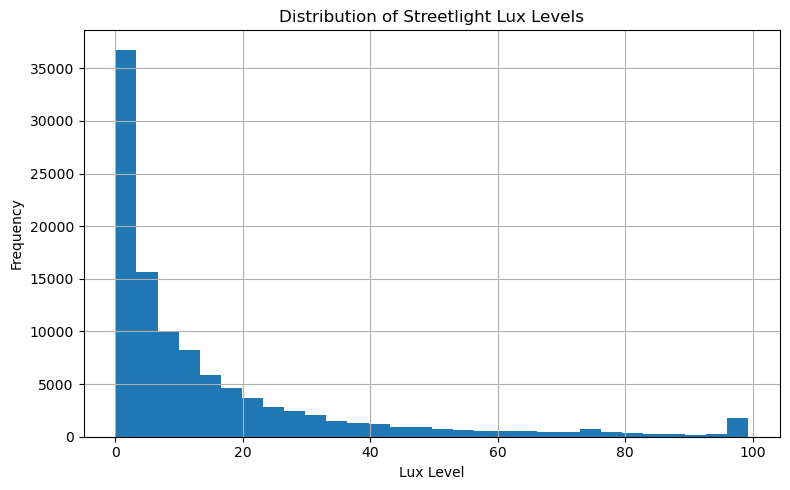

In [8]:
plt.figure(figsize=(8,5))
street_clean['label'].dropna().hist(bins=30)
plt.title("Distribution of Streetlight Lux Levels")
plt.xlabel("Lux Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/streetlight_lux_distribution.png")
plt.show()

**Output interpretation:**  
The histogram shows how streetlight lux values are distributed across the dataset. If most values are concentrated in one range, it suggests that many streetlights have similar lighting intensity. Any very high or very low values may indicate variation in lighting levels across different locations.

### Streetlight concentration by road segment

This chart shows the top road segments with the highest number of streetlights. It provides an early view of where lighting infrastructure is concentrated.

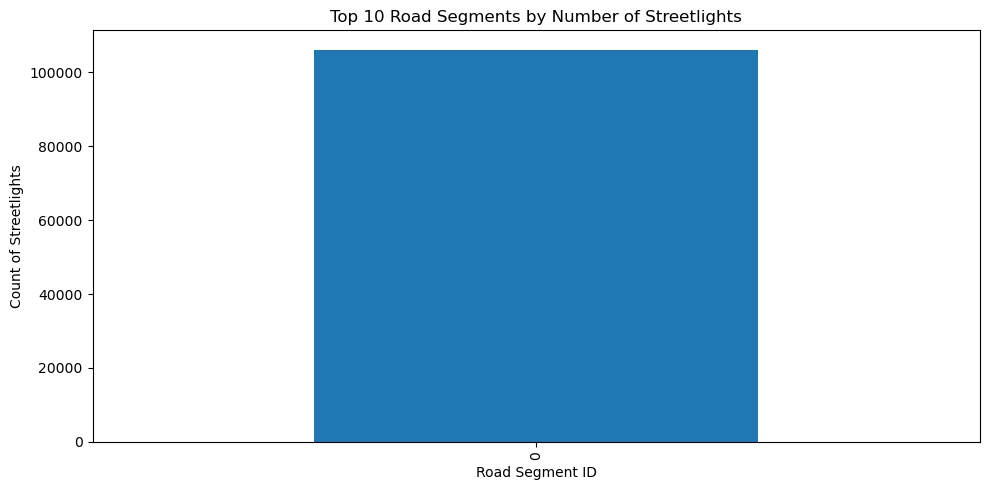

In [9]:
top_segments = street_clean['roadseg_id'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_segments.plot(kind='bar')
plt.title("Top 10 Road Segments by Number of Streetlights")
plt.xlabel("Road Segment ID")
plt.ylabel("Count of Streetlights")
plt.tight_layout()
plt.savefig("outputs/top_road_segments_streetlights.png")
plt.show()


**Output interpretation:**  
This bar chart shows the road segments with the highest number of streetlights. Road segments with more streetlights may represent areas with higher lighting infrastructure concentration. This helps understand where streetlight assets are more densely located.

## 5. Traffic data cleaning

The traffic dataset contains multiple vehicle class columns. This step identifies all vehicle-related columns and prepares them for calculating a single total vehicle count.

In [10]:
vehicle_cols = [col for col in traffic.columns if "vehicle" in col.lower()]

print("\nVehicle columns found:")
print(vehicle_cols)


Vehicle columns found:
['vehicle_class_1', 'vehicle_class_2', 'vehicle_class_3', 'vehicle_class_4', 'vehicle_class_5', 'vehicle_class_6', 'vehicle_class_7', 'vehicle_class_8', 'vehicle_class_9', 'vehicle_class_10', 'vehicle_class_11', 'vehicle_class_12', 'vehicle_class_13']


**Explanation:**  
This code identifies all traffic dataset columns that contain the word `vehicle`. These columns represent different vehicle categories and are needed to calculate the overall traffic activity level.

**Output interpretation:**  
The printed list confirms which vehicle-related columns were found. These columns are later summed to create one total vehicle count measure.

### Creating total vehicle count

All vehicle class columns are summed into `total_vehicles`. This creates one clear traffic activity measure for each record.

In [11]:
traffic['total_vehicles'] = traffic[vehicle_cols].sum(axis=1, skipna=True)

**Explanation:**  
This code adds together all vehicle-related columns to create a new column called `total_vehicles`. This gives one combined traffic activity value for each row.

**Expected output:**  
This cell may not show a visible output, but it adds a new column to the traffic dataframe. This column is used later to calculate hourly traffic levels.

### Extracting hourly traffic activity

The time column is converted into an hour value so traffic can be analysed by hour of the day. Rows without valid hour information are removed to keep the analysis reliable.

In [12]:
if 'date' in traffic.columns:
    traffic['date'] = pd.to_datetime(traffic['date'], errors='coerce')

if 'time' in traffic.columns:
    traffic['hour'] = pd.to_datetime(traffic['time'], format='%H:%M', errors='coerce').dt.hour
elif 'hour' in traffic.columns:
    traffic['hour'] = pd.to_numeric(traffic['hour'], errors='coerce')
else:
    raise ValueError("No suitable time/hour column found in traffic.csv")

print("\nTraffic data sample:")
print(traffic[['total_vehicles', 'hour']].head())


Traffic data sample:
   total_vehicles  hour
0             0.0     3
1             7.0    20
2             0.0     1
3             6.0    11
4             3.0     6


In [13]:
traffic_clean = traffic.dropna(subset=['hour']).copy()
traffic_clean['hour'] = traffic_clean['hour'].astype(int)

In [14]:
print("Cleaned traffic dataset shape:", traffic_clean.shape)


Cleaned traffic dataset shape: (60168, 30)


**Explanation:**  
This code converts the date and time information into usable formats and extracts the hour of the day. Rows with missing hour values are removed so that hourly traffic analysis is reliable.

**Output interpretation:**  
The cleaned traffic dataset shape shows how many records remain after removing rows with invalid or missing hour values. This confirms the data is ready for hourly grouping.

## 6. Traffic visualisation

The traffic data is grouped by hour to calculate the average vehicle count for each hour. This helps identify peak and low traffic periods.

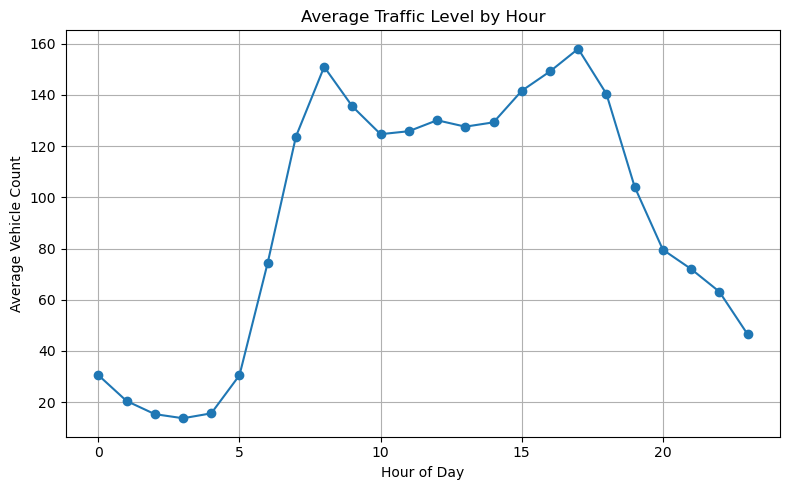

In [15]:
traffic_hour = traffic_clean.groupby('hour')['total_vehicles'].mean().reset_index()
traffic_hour.rename(columns={'total_vehicles': 'traffic_level'}, inplace=True)

plt.figure(figsize=(8,5))
plt.plot(traffic_hour['hour'], traffic_hour['traffic_level'], marker='o')
plt.title("Average Traffic Level by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/traffic_by_hour.png")
plt.show()

**Output interpretation:**  
The line graph shows average traffic activity across each hour of the day. Higher points indicate peak traffic periods, while lower points indicate quieter periods. This helps identify when road activity may require stronger lighting support.

### Optional traffic road analysis

If road names are available, this chart shows the roads with the highest total vehicle counts. This is useful for understanding where major traffic activity is concentrated.

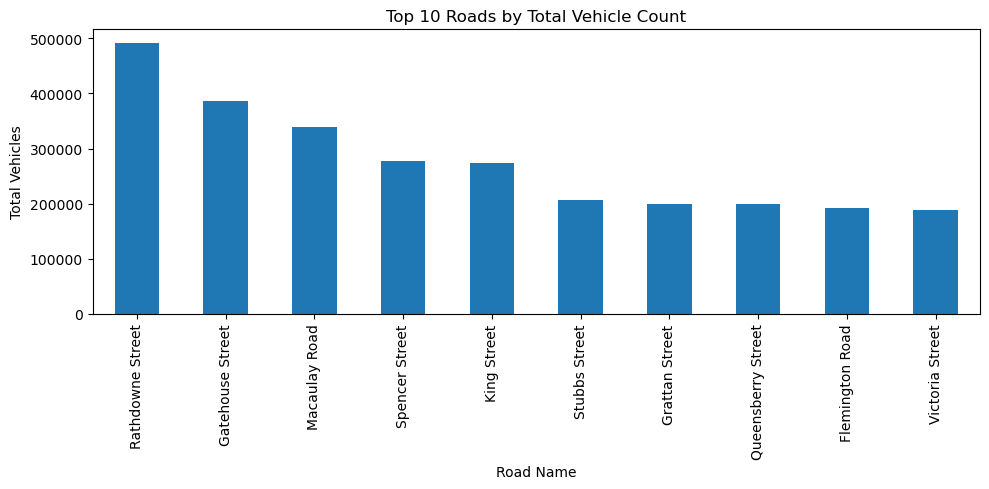

In [16]:
if 'road_name' in traffic_clean.columns:
    top_roads = traffic_clean.groupby('road_name')['total_vehicles'].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(10,5))
    top_roads.plot(kind='bar')
    plt.title("Top 10 Roads by Total Vehicle Count")
    plt.xlabel("Road Name")
    plt.ylabel("Total Vehicles")
    plt.tight_layout()
    plt.savefig("outputs/top_traffic_roads.png")
    plt.show()


**Output interpretation:**  
This bar chart shows the roads with the highest total vehicle counts. These roads may represent important traffic corridors where lighting demand could be higher due to frequent vehicle movement.

## 7. Pedestrian data cleaning

The pedestrian dataset uses `Sensing_Date`, `HourDay`, and `Total_of_Directions`. This step converts the date, hour, and pedestrian count fields into usable formats, then removes incomplete rows.

In [17]:
print("Pedestrian columns:")
print(ped.columns.tolist())

ped.columns = ped.columns.str.strip()

ped['Sensing_Date'] = pd.to_datetime(ped['Sensing_Date'], errors='coerce')

ped['HourDay'] = pd.to_numeric(ped['HourDay'], errors='coerce')

ped['pedestrian_count'] = pd.to_numeric(ped['Total_of_Directions'], errors='coerce')

ped_clean = ped.dropna(subset=['Sensing_Date', 'HourDay', 'pedestrian_count']).copy()

ped_clean['hour'] = ped_clean['HourDay'].astype(int)

print("\nCleaned pedestrian dataset shape:", ped_clean.shape)
print("\nPedestrian cleaned sample:")
print(ped_clean[['Sensing_Date', 'hour', 'pedestrian_count', 'Sensor_Name', 'Location']].head())

Pedestrian columns:
['ID', 'Location_ID', 'Sensing_Date', 'HourDay', 'Direction_1', 'Direction_2', 'Total_of_Directions', 'Sensor_Name', 'Location']

Cleaned pedestrian dataset shape: (1472098, 11)

Pedestrian cleaned sample:
  Sensing_Date  hour  pedestrian_count Sensor_Name                    Location
0   2026-01-05     4                41      FliS_T  -37.81911705, 144.96558255
1   2024-08-12    23               378    Swa295_T  -37.81101524, 144.96429485
2   2024-09-11     4                23    Swa295_T  -37.81101524, 144.96429485
3   2025-09-07     1               591    Swa295_T  -37.81101524, 144.96429485
4   2024-11-07    17               680      RMIT_T  -37.80825648, 144.96304859


**Explanation:**  
This code cleans the pedestrian dataset by converting the sensing date, hour, and pedestrian count fields into usable formats. It removes incomplete records and creates a clean hourly pedestrian activity dataset.

**Output interpretation:**  
The cleaned pedestrian dataset shape shows how many valid records remain after cleaning. The sample output confirms that the date, hour, pedestrian count, sensor name, and location values are correctly prepared.

## 8. Pedestrian visualisation

The pedestrian data is grouped by hour to calculate average pedestrian activity. This shows when pedestrian movement is higher or lower throughout the day.

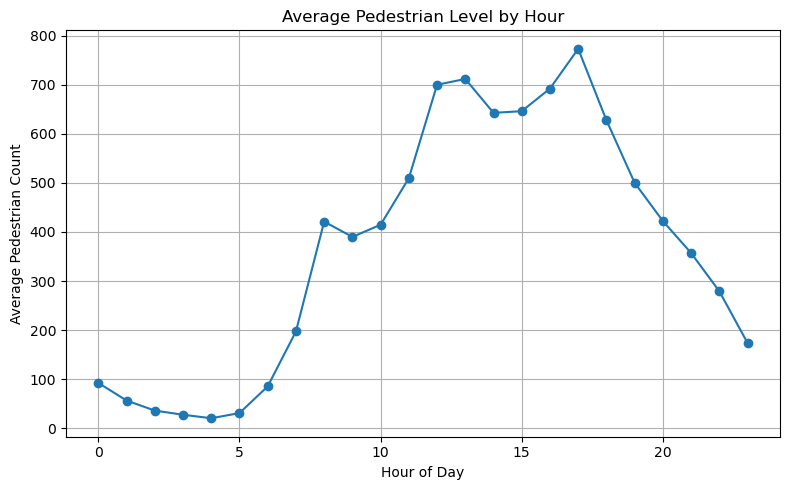

In [18]:
ped_hour = ped_clean.groupby('hour')['pedestrian_count'].mean().reset_index()
ped_hour.rename(columns={'pedestrian_count': 'pedestrian_level'}, inplace=True)

plt.figure(figsize=(8,5))
plt.plot(ped_hour['hour'], ped_hour['pedestrian_level'], marker='o')
plt.title("Average Pedestrian Level by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Pedestrian Count")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/pedestrian_by_hour.png")
plt.show()

**Output interpretation:**  
The line graph shows average pedestrian movement across each hour of the day. Higher values indicate busier pedestrian periods, while lower values indicate quieter times. This information is important because pedestrian safety is a key factor in smart lighting decisions.

## 9. Data integration

Traffic and pedestrian datasets are merged using the common `hour` column. This time-based integration was selected because the datasets do not align perfectly by exact location. Static streetlight summary features are then added to the merged activity dataset.

In [19]:
merged_activity = traffic_hour.merge(ped_hour, on='hour', how='inner')

merged_activity['streetlight_count'] = streetlight_count
merged_activity['avg_lux'] = avg_lux

print("\nMerged activity data:")
print(merged_activity.head())



Merged activity data:
   hour  traffic_level  pedestrian_level  streetlight_count    avg_lux
0     0      30.529717         92.537110             106037  15.044992
1     1      20.445154         56.666506             106037  15.044992
2     2      15.305146         36.245961             106037  15.044992
3     3      13.698843         27.767305             106037  15.044992
4     4      15.617072         20.630454             106037  15.044992


**Explanation:**  
This code merges the hourly traffic and pedestrian datasets using the common `hour` column. It then adds static streetlight information, including total streetlight count and average lux level.

**Output interpretation:**  
The merged output table confirms that traffic level, pedestrian level, streetlight count, and average lux are now available in one combined dataset. This integrated dataset is used for demand score calculation and efficiency analysis.

### 10.Demand Score Weight Justification
The demand score combines traffic activity and pedestrian activity using a weighted approach, where traffic contributes 60% and pedestrian activity contributes 40%.

Traffic activity is weighted higher because vehicle movement generally has a greater impact on road safety, visibility requirements, and overall lighting demand. Roads with higher traffic flow usually require stronger and more consistent lighting to support driver visibility and reduce safety risks.

Pedestrian activity is still included because pedestrian safety, walkability, and public comfort are also important in smart city lighting decisions. The 60/40 weighting is used as a practical initial assumption and can be improved in future work using official lighting standards or real sensor-based lighting data.

In [20]:
merged_activity['demand_score'] = (
    merged_activity['traffic_level'] * 0.6 +
    merged_activity['pedestrian_level'] * 0.4
)
print("\nDemand score summary:")
print(merged_activity['demand_score'].describe())


Demand score summary:
count     24.000000
mean     201.881949
std      131.550715
min       17.622425
25%       73.005599
50%      226.958073
75%      334.791311
max      404.016515
Name: demand_score, dtype: float64


**Explanation:**  
This code creates the `demand_score` by combining traffic activity and pedestrian activity. Traffic is given 60% weight and pedestrian activity is given 40% weight.

Traffic is weighted higher because vehicle movement usually has a stronger impact on road safety, visibility needs, and lighting demand. Pedestrian activity is also included because pedestrian safety and walkability are important in urban lighting decisions.

**Output interpretation:**  
The demand score summary shows the count, mean, minimum, maximum, and quartile values. These statistics help understand how activity demand changes across the day and support the next step of efficiency classification.

## 11. Efficiency classification

The demand score is split into three ranges using quantiles. Low-demand hours are classified as **over-lit**, high-demand hours are classified as **under-lit**, and middle-demand hours are classified as **efficient**. This makes the classification data-driven instead of manually choosing fixed thresholds.

In [21]:
low_threshold = merged_activity['demand_score'].quantile(0.33)
high_threshold = merged_activity['demand_score'].quantile(0.66)
print("\nLow threshold:", low_threshold)
print("High threshold:", high_threshold)
def classify(row):
    if row['demand_score'] >= high_threshold:
        return "under-lit"
    elif row['demand_score'] <= low_threshold:
        return "over-lit"
    else:
        return "efficient"
merged_activity['efficiency'] = merged_activity.apply(classify, axis=1)


Low threshold: 128.23769237558594
High threshold: 265.5425818034572


### Limitation of Quantile-Based Classification
The efficiency categories were created using quantile-based thresholds from the demand score. This was used as an initial data-driven method because the datasets did not include official lighting thresholds or council-defined activity standards.

However, a limitation of quantile-based classification is that it can divide the data into roughly balanced groups even if the real-world lighting demand is not evenly distributed. This means the model may classify some hours as under-lit or over-lit based on relative demand rather than actual lighting standards.

In future work, domain-based thresholds using council lighting guidelines, lux standards, energy consumption data, or sensor-level streetlight data could be used to produce more realistic classifications.

## 12. Recommendation analysis

The recommendation logic converts each efficiency category into a practical action. Under-lit hours suggest increasing lighting, over-lit hours suggest reducing lighting, and efficient hours suggest maintaining the current setting.

In [22]:
def recommend(row):
    if row['efficiency'] == "under-lit":
        return "Increase lighting during peak activity hours"
    elif row['efficiency'] == "over-lit":
        return "Reduce lighting during low activity hours"
    else:
        return "Lighting is optimal for current activity"
merged_activity['recommendation'] = merged_activity.apply(recommend, axis=1)
print("\nFinal efficiency and recommendation output:")
print(
    merged_activity[
        [
            'hour',
            'traffic_level',
            'pedestrian_level',
            'demand_score',
            'efficiency',
            'recommendation'
        ]
    ]
)


Final efficiency and recommendation output:
    hour  traffic_level  pedestrian_level  demand_score efficiency  \
0      0      30.529717         92.537110     55.332674   over-lit   
1      1      20.445154         56.666506     34.933695   over-lit   
2      2      15.305146         36.245961     23.681472   over-lit   
3      3      13.698843         27.767305     19.326228   over-lit   
4      4      15.617072         20.630454     17.622425   over-lit   
5      5      30.508576         31.190856     30.781488   over-lit   
6      6      74.432389         85.592852     78.896574   over-lit   
7      7     123.749900        197.337836    153.185075  efficient   
8      8     150.990028        421.070487    259.022212  efficient   
9      9     135.509374        389.925675    237.275894  efficient   
10    10     124.673714        414.695177    240.682299  efficient   
11    11     125.838053        509.529459    279.314616  under-lit   
12    12     130.120463        699.798749    

**Explanation:**  
This code converts each efficiency category into a practical recommendation. Under-lit hours suggest increasing lighting, over-lit hours suggest reducing lighting, and efficient hours suggest maintaining current lighting.

**Output interpretation:**  
The final table shows the hour, traffic level, pedestrian level, demand score, efficiency category, and recommendation. This is the main output of the use case because it converts raw activity data into practical smart lighting decisions.

## 13. Final visualisations

The final graphs summarise the efficiency categories, demand score by hour, and the relationship between traffic and pedestrian activity. These outputs can be used as visual evidence in the project submission.

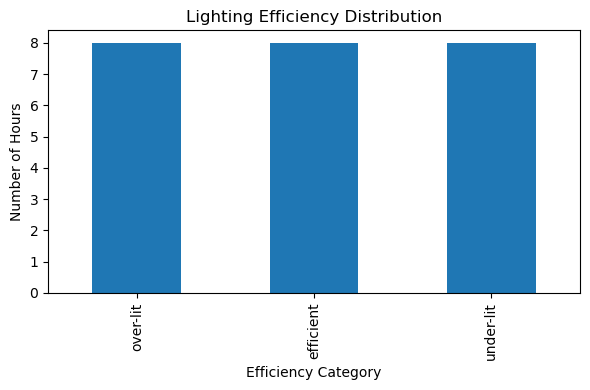

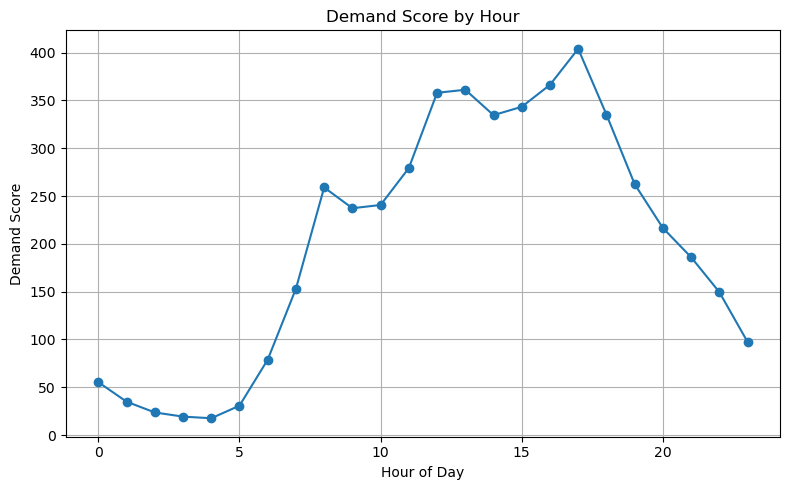

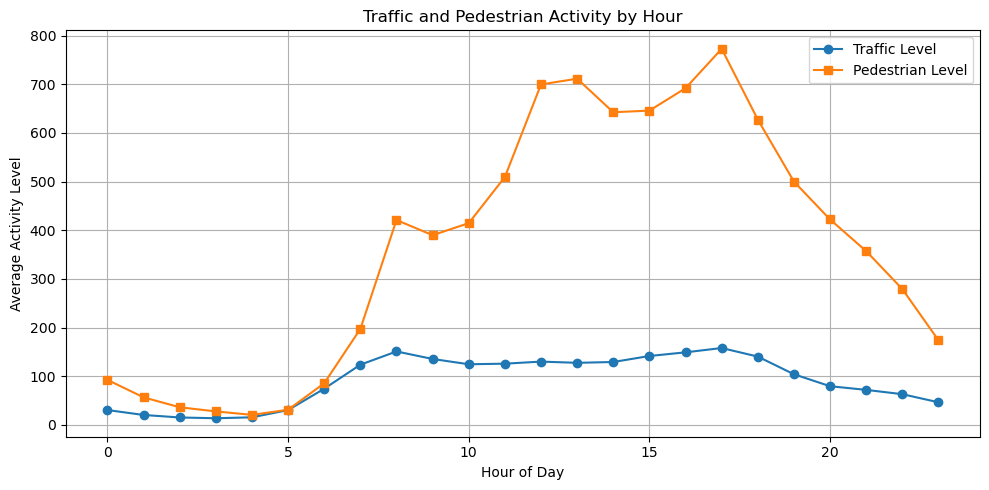

In [74]:
plt.figure(figsize=(6,4))
merged_activity['efficiency'].value_counts().plot(kind='bar')
plt.title("Lighting Efficiency Distribution")
plt.xlabel("Efficiency Category")
plt.ylabel("Number of Hours")
plt.tight_layout()
plt.savefig("outputs/efficiency_distribution.png")
plt.show()
plt.figure(figsize=(8,5))
plt.plot(merged_activity['hour'], merged_activity['demand_score'], marker='o')
plt.title("Demand Score by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Demand Score")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/demand_score_by_hour.png")
plt.show()
plt.figure(figsize=(10,5))
plt.plot(merged_activity['hour'], merged_activity['traffic_level'], marker='o', label='Traffic Level')
plt.plot(merged_activity['hour'], merged_activity['pedestrian_level'], marker='s', label='Pedestrian Level')
plt.title("Traffic and Pedestrian Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Activity Level")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/activity_by_hour.png")
plt.show()

### Output Interpretation

The efficiency distribution graph summarises how many hours were classified as under-lit, efficient, or over-lit. This helps provide an overall understanding of the lighting efficiency patterns identified by the model.

The demand score by hour graph shows how combined traffic and pedestrian activity changes throughout the day. Higher demand score periods indicate busier hours where stronger lighting may be required, while lower demand score periods indicate quieter hours with potentially unnecessary lighting usage.

The traffic vs pedestrian activity graph compares both activity patterns across different hours. The graph helps show whether vehicle movement and pedestrian movement follow similar trends or peak at different times. This comparison supports the decision to combine both activity types in the demand score calculation.

Together, these visualisations help explain how activity levels influence lighting efficiency classification and recommendation generation in the smart street lighting model.

## 14. Saving final results

The final output table is saved as a CSV file. This provides a reusable project output showing hourly activity, demand score, efficiency classification, and recommendation.

In [75]:
final_output = merged_activity[
    [
        'hour',
        'traffic_level',
        'pedestrian_level',
        'streetlight_count',
        'avg_lux',
        'demand_score',
        'efficiency',
        'recommendation'
    ]
]
final_output.to_csv("outputs/final_lighting_efficiency_summary.csv", index=False)
print("\nFinal output saved:")
print("outputs/final_lighting_efficiency_summary.csv")


Final output saved:
outputs/final_lighting_efficiency_summary.csv


**Explanation:**  
This code saves the final output table as a CSV file in the `outputs` folder. The saved file includes hourly traffic level, pedestrian level, streetlight information, demand score, efficiency category, and recommendation.

**Output interpretation:**  
If the file path is printed successfully, it confirms that the final result has been exported and can be used as evidence for submission or further analysis.

## 15. Key Observations, Limitations and Future Work

### Key Observations
The analysis shows that traffic and pedestrian activity change noticeably across different hours of the day. Low-activity hours are mostly classified as over-lit, while high-activity hours are classified as under-lit. Medium-demand hours are classified as efficient.

### Limitations
The streetlight dataset does not directly match the traffic and pedestrian datasets using a common location key. Because of this, the integration was completed using hourly activity patterns rather than exact spatial matching.

The efficiency classification uses quantile-based thresholds. This makes the classification data-driven, but it may create balanced categories even when real-world lighting conditions are not evenly distributed.

### Future Work
Future improvements could include using location-based matching, sensor-level streetlight data, real lux standards, and domain-based lighting thresholds to make the classification more realistic.